In [44]:
# LE BUT DE CE NOTEBOOK EST DE CRÉÉER DES FIGURES PLUS ÉLABORÉS 
# non seulement pour la présenttaion finale de brainHACK mais aussi pour mes futures présentations de lab
# 06 - Presentation Figures

#Objective:

#create clean, presentation-ready figures for the final BrainHack presentation.

#These figures are designed for communication rather than exploratory analysis.


#- the study sample;
#- the EEG regional feature construction;
#- ANCOVA findings;
#- classifier performance;
#- robust biomarkers;
#- regional versus global prediction.


#Outputs:

#`figures/presentation/`

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import Normalize

PROJECT_ROOT = Path("..")

RESULTS_DIR = PROJECT_ROOT / "results"
ML_RESULTS_DIR = RESULTS_DIR / "ml"
ML_GLOBAL_DIR = RESULTS_DIR / "ml_global"

FIGURES_DIR = PROJECT_ROOT / "figures" / "presentation"
TEMPLATE_DIR = PROJECT_ROOT / "figures" / "templates"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BRAIN_IMG = TEMPLATE_DIR / "brain_top_view.webp"

print("Brain template exists:", BRAIN_IMG.exists())

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

palette = {
    "dark": "#2D1238",
    "white": "#FFFFFF",
    "gray": "#6C757D",

    "frontal": "#BDE0FE",
    "central": "#A8E6CF",
    "parietal": "#D7BDE2",
    "occipital": "#FFE29A",

    "frontal_dark": "#2878B5",
    "central_dark": "#2E8B57",
    "parietal_dark": "#7D3C98",
    "occipital_dark": "#C27C00",

    "soft_bg": "#FFF8FC",
    "soft_box": "#F3E6F5",
}

Brain template exists: True


In [50]:
# fonction du cerveau complet 


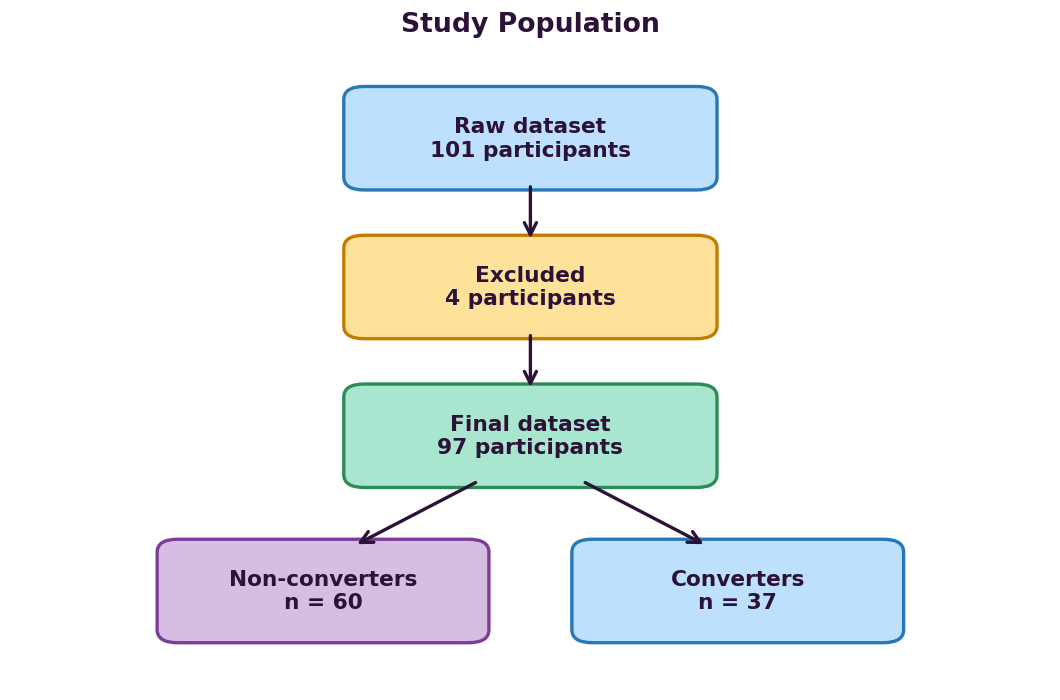

In [54]:
# figure 1 : population étudiée
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")

def draw_box(ax, x, y, text, color, edge, width=0.32, height=0.12):
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor=edge,
        linewidth=2,
    )
    ax.add_patch(box)

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=palette["dark"],
    )

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=2,
            color=palette["dark"],
        )
    )

draw_box(
    ax,
    0.5,
    0.85,
    "Raw dataset\n101 participants",
    palette["frontal"],
    palette["frontal_dark"],
)

draw_box(
    ax,
    0.5,
    0.62,
    "Excluded\n4 participants",
    palette["occipital"],
    palette["occipital_dark"],
)

draw_box(
    ax,
    0.5,
    0.39,
    "Final dataset\n97 participants",
    palette["central"],
    palette["central_dark"],
)

arrow(ax, 0.5, 0.78, 0.5, 0.69)
arrow(ax, 0.5, 0.55, 0.5, 0.46)

draw_box(
    ax,
    0.30,
    0.15,
    "Non-converters\nn = 60",
    palette["parietal"],
    palette["parietal_dark"],
    width=0.28,
)

draw_box(
    ax,
    0.70,
    0.15,
    "Converters\nn = 37",
    palette["frontal"],
    palette["frontal_dark"],
    width=0.28,
)

arrow(ax, 0.45, 0.32, 0.33, 0.22)
arrow(ax, 0.55, 0.32, 0.67, 0.22)

ax.set_title(
    "Study Population",
    fontweight="bold",
    color=palette["dark"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "study_population.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

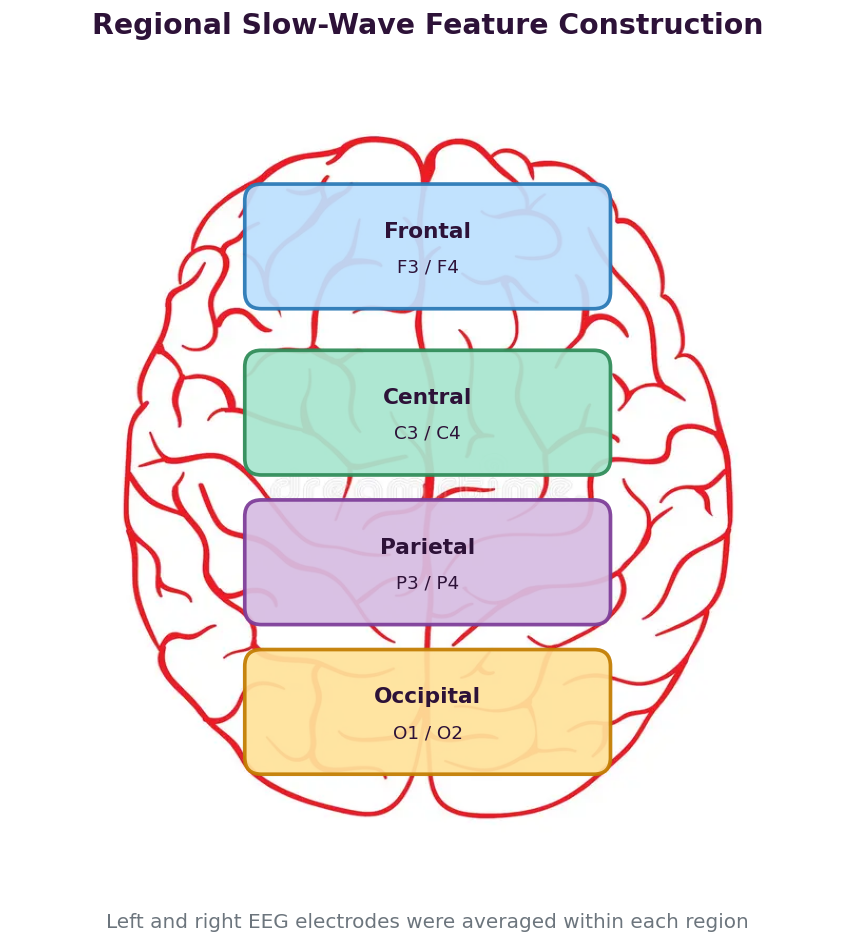

In [55]:
# Figure 2 pour mettre en évidence les régions cérébrales et les électrodes

brain_img = plt.imread(BRAIN_IMG)

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    brain_img,
    extent=[0, 1, 0, 1],
)

ax.axis("off")

regions = [
    {
        "name": "Frontal",
        "electrodes": "F3 / F4",
        "xy": (0.50, 0.78),
        "color": palette["frontal"],
        "edge": palette["frontal_dark"],
    },
    {
        "name": "Central",
        "electrodes": "C3 / C4",
        "xy": (0.50, 0.58),
        "color": palette["central"],
        "edge": palette["central_dark"],
    },
    {
        "name": "Parietal",
        "electrodes": "P3 / P4",
        "xy": (0.50, 0.40),
        "color": palette["parietal"],
        "edge": palette["parietal_dark"],
    },
    {
        "name": "Occipital",
        "electrodes": "O1 / O2",
        "xy": (0.50, 0.22),
        "color": palette["occipital"],
        "edge": palette["occipital_dark"],
    },
]

for region in regions:
    x, y = region["xy"]

    box = FancyBboxPatch(
        (x - 0.20, y - 0.055),
        0.40,
        0.11,
        boxstyle="round,pad=0.02",
        facecolor=region["color"],
        edgecolor=region["edge"],
        linewidth=2.2,
        alpha=0.93,
    )

    ax.add_patch(box)

    ax.text(
        x,
        y + 0.018,
        region["name"],
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        y - 0.025,
        region["electrodes"],
        ha="center",
        va="center",
        fontsize=11,
        color=palette["dark"],
    )

ax.set_title(
    "Regional Slow-Wave Feature Construction",
    fontsize=17,
    fontweight="bold",
    color=palette["dark"],
    pad=18,
)

ax.text(
    0.50,
    -0.04,
    "Left and right EEG electrodes were averaged within each region",
    ha="center",
    fontsize=12,
    color=palette["gray"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "brain_regions_electrodes_template.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

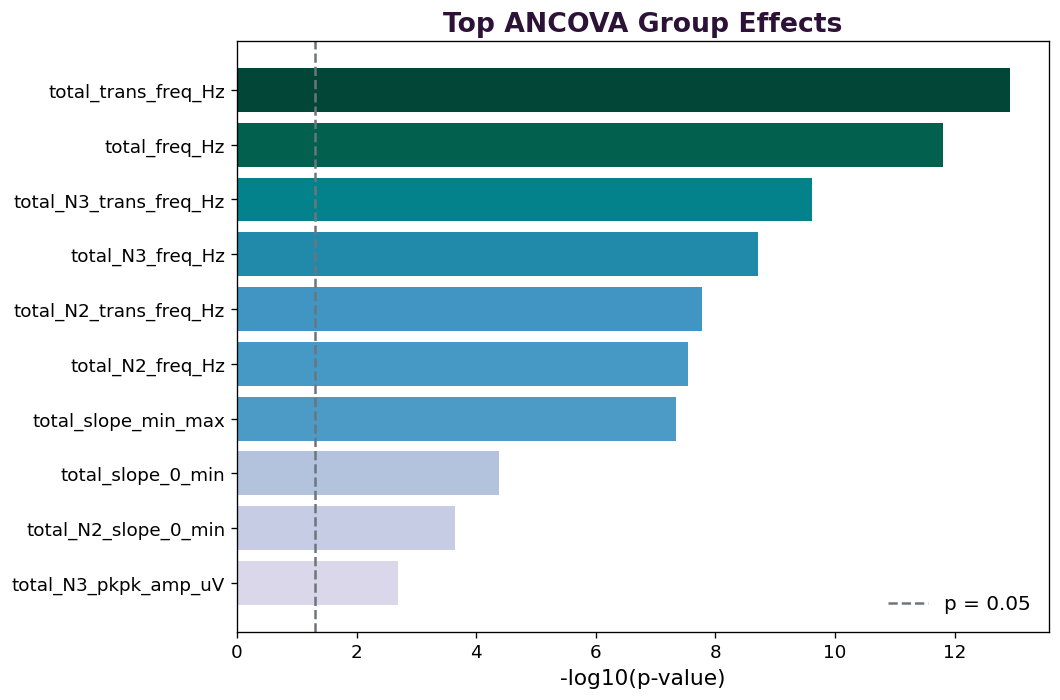

In [57]:
# figure 3 : résumé de l'ANCOVA
ancova = pd.read_csv(
    RESULTS_DIR / "ancova" / "repeated_measures_ancova_all_effects.csv"
)

group_effects = ancova[
    ancova["effect"] == "C(conversion_status)"
].copy()

group_effects["neg_log10_p"] = -np.log10(
    group_effects["PR(>F)"]
)

top_ancova = (
    group_effects
    .sort_values("PR(>F)")
    .head(10)
    .sort_values("neg_log10_p")
)

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.PuBuGn(
    top_ancova["neg_log10_p"] /
    top_ancova["neg_log10_p"].max()
)

ax.barh(
    top_ancova["variable"],
    top_ancova["neg_log10_p"],
    color=colors,
)

ax.axvline(
    -np.log10(0.05),
    linestyle="--",
    color=palette["gray"],
    linewidth=1.5,
    label="p = 0.05",
)

ax.set_xlabel("-log10(p-value)")

ax.set_title(
    "Top ANCOVA Group Effects",
    fontweight="bold",
    color=palette["dark"],
)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ancova_top_group_effects.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

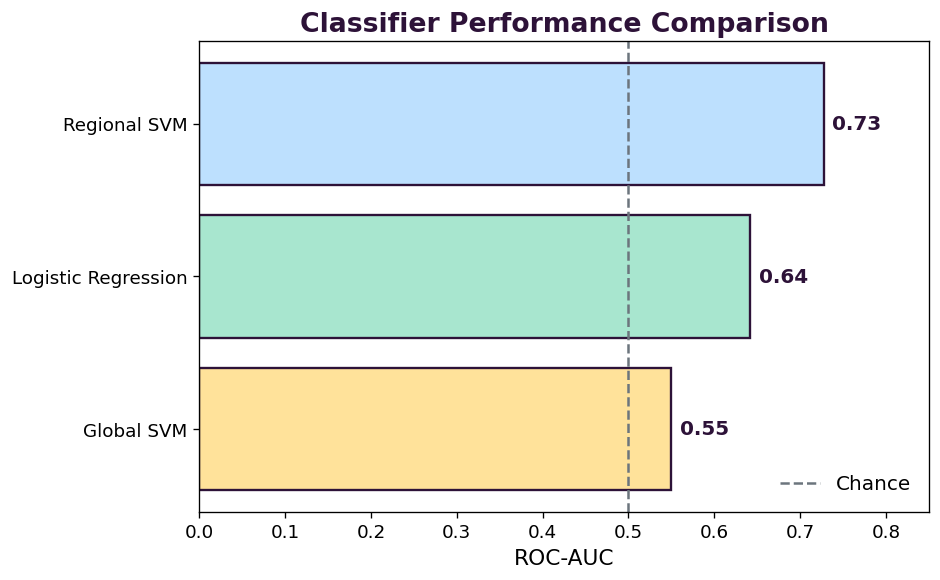

In [58]:
# figure 4 : classificateur ROC-AUC comparison
regional = pd.read_csv(
    ML_RESULTS_DIR / "classification_metrics.csv",
    index_col=0,
)

logistic = pd.read_csv(
    ML_RESULTS_DIR / "logistic_regression_metrics.csv",
    index_col=0,
)

global_model = pd.read_csv(
    ML_GLOBAL_DIR / "classification_metrics.csv",
    index_col=0,
)

auc_df = pd.DataFrame({
    "Model": [
        "Regional SVM",
        "Logistic Regression",
        "Global SVM",
    ],
    "ROC-AUC": [
        regional.loc["roc_auc", "0"],
        logistic.loc["roc_auc", "0"],
        global_model.loc["roc_auc", "0"],
    ],
})

auc_df = auc_df.sort_values("ROC-AUC")

fig, ax = plt.subplots(figsize=(8, 5))

colors = [
    palette["occipital"],
    palette["central"],
    palette["frontal"],
]

ax.barh(
    auc_df["Model"],
    auc_df["ROC-AUC"],
    color=colors,
    edgecolor=palette["dark"],
    linewidth=1.4,
)

ax.axvline(
    0.5,
    linestyle="--",
    color=palette["gray"],
    linewidth=1.5,
    label="Chance",
)

for i, value in enumerate(auc_df["ROC-AUC"]):
    ax.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        fontweight="bold",
        color=palette["dark"],
    )

ax.set_xlim(0, 0.85)
ax.set_xlabel("ROC-AUC")

ax.set_title(
    "Classifier Performance Comparison",
    fontweight="bold",
    color=palette["dark"],
)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "classifier_auc_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

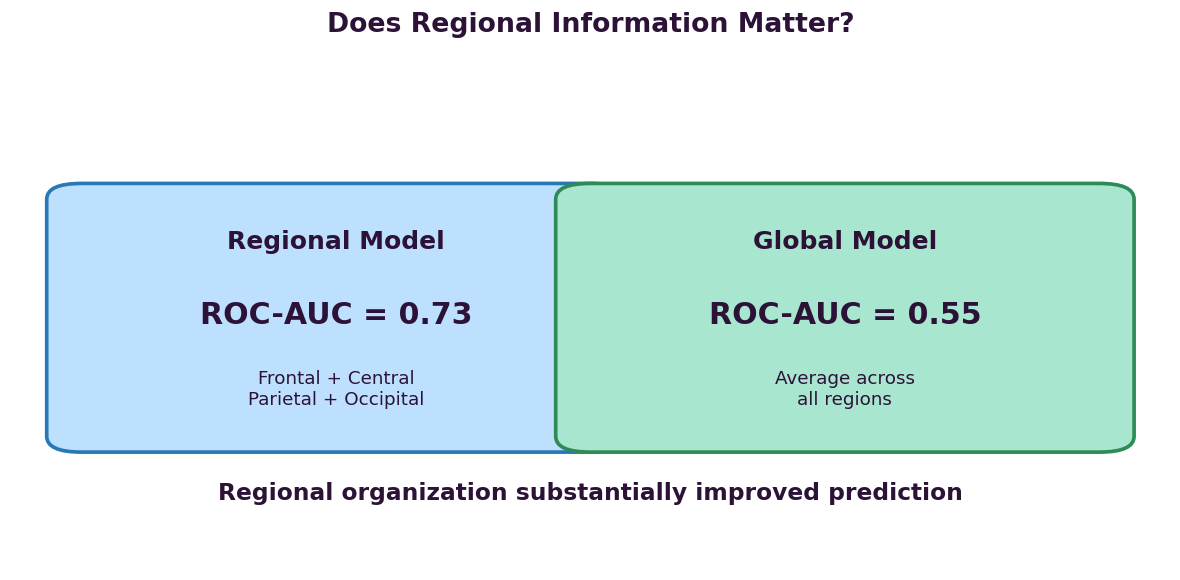

In [59]:
# figure 5 : classifier régional vs global
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

def model_card(x, title, auc, subtitle, color, edge):
    box = FancyBboxPatch(
        (x - 0.22, 0.25),
        0.44,
        0.45,
        boxstyle="round,pad=0.03",
        facecolor=color,
        edgecolor=edge,
        linewidth=2.2,
    )

    ax.add_patch(box)

    ax.text(
        x,
        0.62,
        title,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        0.48,
        f"ROC-AUC = {auc:.2f}",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        0.34,
        subtitle,
        ha="center",
        va="center",
        fontsize=11,
        color=palette["dark"],
    )

model_card(
    0.28,
    "Regional Model",
    0.728,
    "Frontal + Central\nParietal + Occipital",
    palette["frontal"],
    palette["frontal_dark"],
)

model_card(
    0.72,
    "Global Model",
    0.550,
    "Average across\nall regions",
    palette["central"],
    palette["central_dark"],
)

ax.text(
    0.5,
    0.13,
    "Regional organization substantially improved prediction",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color=palette["dark"],
)

ax.set_title(
    "Does Regional Information Matter?",
    fontweight="bold",
    color=palette["dark"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "regional_vs_global_concept.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

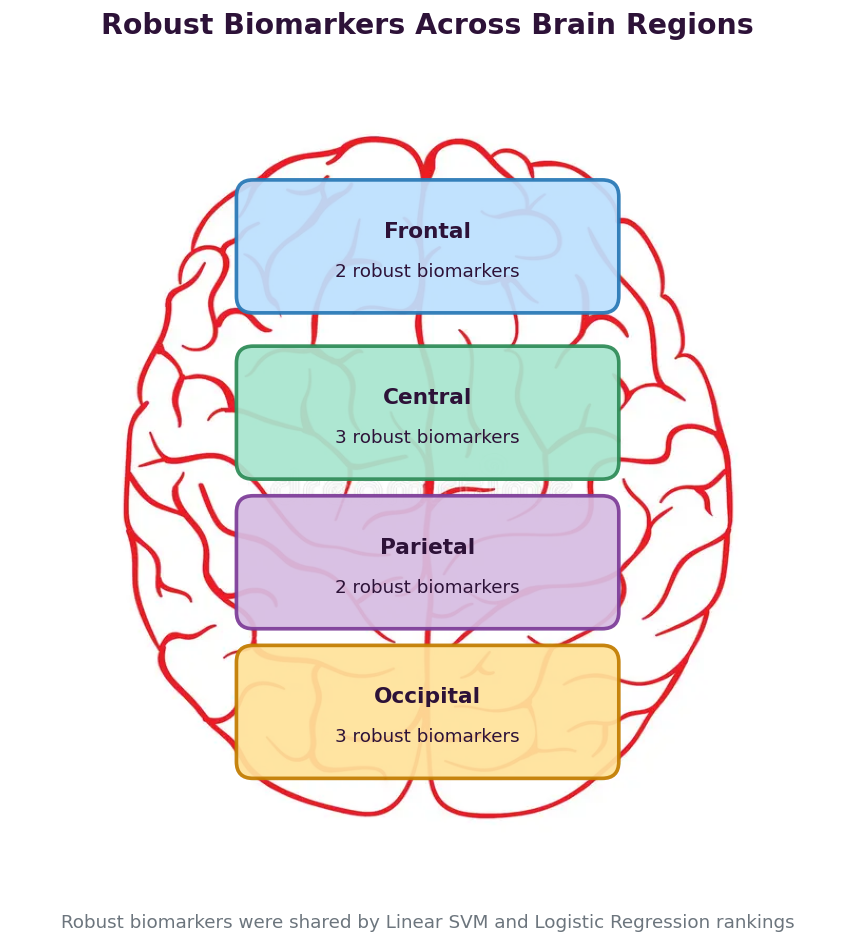

In [62]:
# figure 6 visualisation des biomarkeurs les plus robustes sur un cerveau 
brain_img = plt.imread(BRAIN_IMG)

region_counts = pd.DataFrame({
    "region": [
        "Frontal",
        "Central",
        "Parietal",
        "Occipital",
    ],
    "count": [
        2,
        3,
        2,
        3,
    ],
})

region_positions = {
    "Frontal": (0.50, 0.78),
    "Central": (0.50, 0.58),
    "Parietal": (0.50, 0.40),
    "Occipital": (0.50, 0.22),
}

region_colors = {
    "Frontal": palette["frontal"],
    "Central": palette["central"],
    "Parietal": palette["parietal"],
    "Occipital": palette["occipital"],
}

region_edges = {
    "Frontal": palette["frontal_dark"],
    "Central": palette["central_dark"],
    "Parietal": palette["parietal_dark"],
    "Occipital": palette["occipital_dark"],
}

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    brain_img,
    extent=[0, 1, 0, 1],
)

ax.axis("off")

for _, row in region_counts.iterrows():
    region = row["region"]
    count = row["count"]

    x, y = region_positions[region]

    box = FancyBboxPatch(
        (x - 0.21, y - 0.06),
        0.42,
        0.12,
        boxstyle="round,pad=0.02",
        facecolor=region_colors[region],
        edgecolor=region_edges[region],
        linewidth=2.2,
        alpha=0.93,
    )

    ax.add_patch(box)

    ax.text(
        x,
        y + 0.018,
        region,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        y - 0.030,
        f"{count} robust biomarkers",
        ha="center",
        va="center",
        fontsize=11,
        color=palette["dark"],
    )

ax.set_title(
    "Robust Biomarkers Across Brain Regions",
    fontsize=17,
    fontweight="bold",
    color=palette["dark"],
    pad=18,
)

ax.text(
    0.50,
    -0.04,
    "Robust biomarkers were shared by Linear SVM and Logistic Regression rankings",
    ha="center",
    fontsize=11,
    color=palette["gray"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "robust_biomarkers_brain_template.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

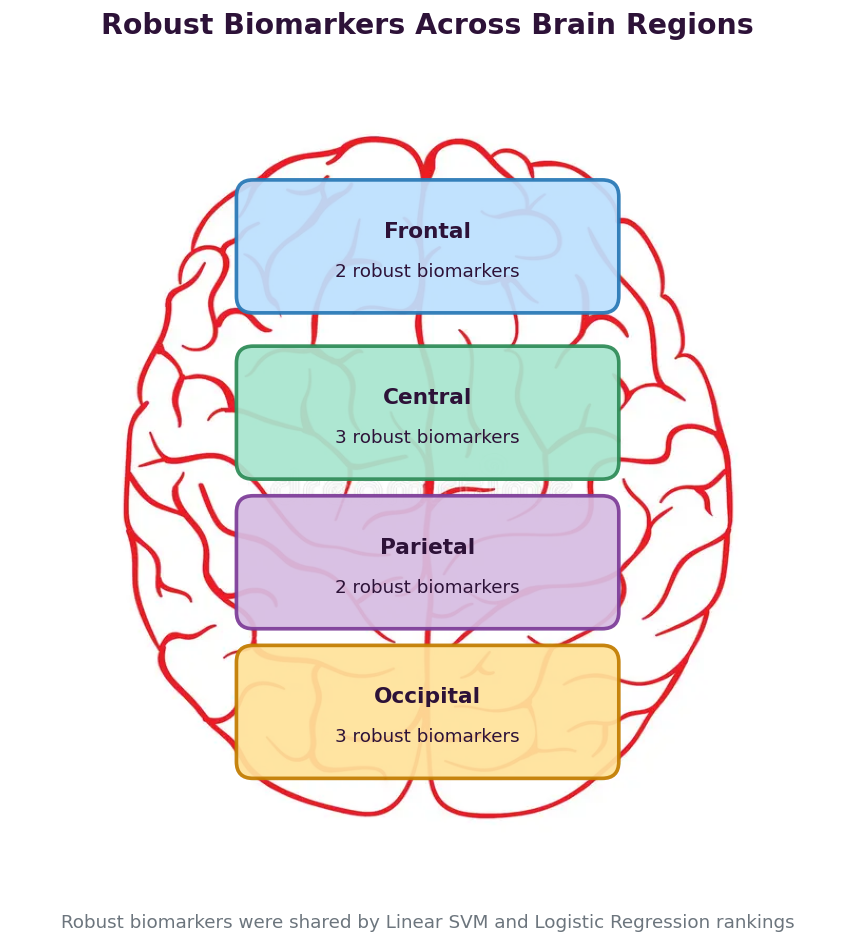

In [63]:
# figure 7 : résumé final du workflow 
brain_img = plt.imread(BRAIN_IMG)

region_counts = pd.DataFrame({
    "region": [
        "Frontal",
        "Central",
        "Parietal",
        "Occipital",
    ],
    "count": [
        2,
        3,
        2,
        3,
    ],
})

region_positions = {
    "Frontal": (0.50, 0.78),
    "Central": (0.50, 0.58),
    "Parietal": (0.50, 0.40),
    "Occipital": (0.50, 0.22),
}

region_colors = {
    "Frontal": palette["frontal"],
    "Central": palette["central"],
    "Parietal": palette["parietal"],
    "Occipital": palette["occipital"],
}

region_edges = {
    "Frontal": palette["frontal_dark"],
    "Central": palette["central_dark"],
    "Parietal": palette["parietal_dark"],
    "Occipital": palette["occipital_dark"],
}

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    brain_img,
    extent=[0, 1, 0, 1],
)

ax.axis("off")

for _, row in region_counts.iterrows():
    region = row["region"]
    count = row["count"]

    x, y = region_positions[region]

    box = FancyBboxPatch(
        (x - 0.21, y - 0.06),
        0.42,
        0.12,
        boxstyle="round,pad=0.02",
        facecolor=region_colors[region],
        edgecolor=region_edges[region],
        linewidth=2.2,
        alpha=0.93,
    )

    ax.add_patch(box)

    ax.text(
        x,
        y + 0.018,
        region,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        y - 0.030,
        f"{count} robust biomarkers",
        ha="center",
        va="center",
        fontsize=11,
        color=palette["dark"],
    )

ax.set_title(
    "Robust Biomarkers Across Brain Regions",
    fontsize=17,
    fontweight="bold",
    color=palette["dark"],
    pad=18,
)

ax.text(
    0.50,
    -0.04,
    "Robust biomarkers were shared by Linear SVM and Logistic Regression rankings",
    ha="center",
    fontsize=11,
    color=palette["gray"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "robust_biomarkers_brain_template.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

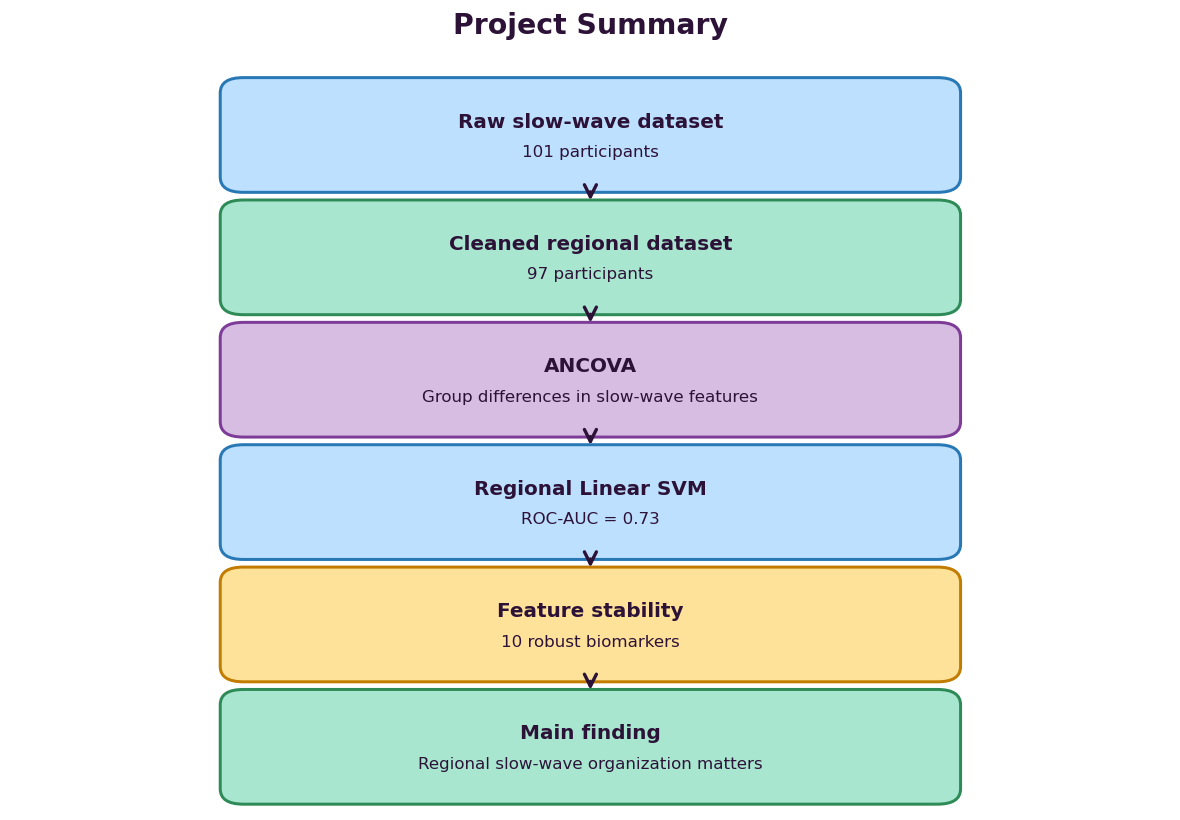

In [64]:
# final project summary 
fig, ax = plt.subplots(figsize=(10, 7))
ax.axis("off")

steps = [
    (
        "Raw slow-wave dataset",
        "101 participants",
        0.5,
        0.88,
        palette["frontal"],
        palette["frontal_dark"],
    ),
    (
        "Cleaned regional dataset",
        "97 participants",
        0.5,
        0.72,
        palette["central"],
        palette["central_dark"],
    ),
    (
        "ANCOVA",
        "Group differences in slow-wave features",
        0.5,
        0.56,
        palette["parietal"],
        palette["parietal_dark"],
    ),
    (
        "Regional Linear SVM",
        "ROC-AUC = 0.73",
        0.5,
        0.40,
        palette["frontal"],
        palette["frontal_dark"],
    ),
    (
        "Feature stability",
        "10 robust biomarkers",
        0.5,
        0.24,
        palette["occipital"],
        palette["occipital_dark"],
    ),
    (
        "Main finding",
        "Regional slow-wave organization matters",
        0.5,
        0.08,
        palette["central"],
        palette["central_dark"],
    ),
]

for title, subtitle, x, y, color, edge in steps:
    box = FancyBboxPatch(
        (x - 0.30, y - 0.055),
        0.60,
        0.11,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor=edge,
        linewidth=1.8,
    )

    ax.add_patch(box)

    ax.text(
        x,
        y + 0.018,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        y - 0.022,
        subtitle,
        ha="center",
        va="center",
        fontsize=10,
        color=palette["dark"],
    )

for i in range(len(steps) - 1):
    _, _, x1, y1, _, _ = steps[i]
    _, _, x2, y2, _, _ = steps[i + 1]

    ax.add_patch(
        FancyArrowPatch(
            (x1, y1 - 0.07),
            (x2, y2 + 0.07),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=2,
            color=palette["dark"],
        )
    )

ax.set_title(
    "Project Summary",
    fontsize=17,
    fontweight="bold",
    color=palette["dark"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_project_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

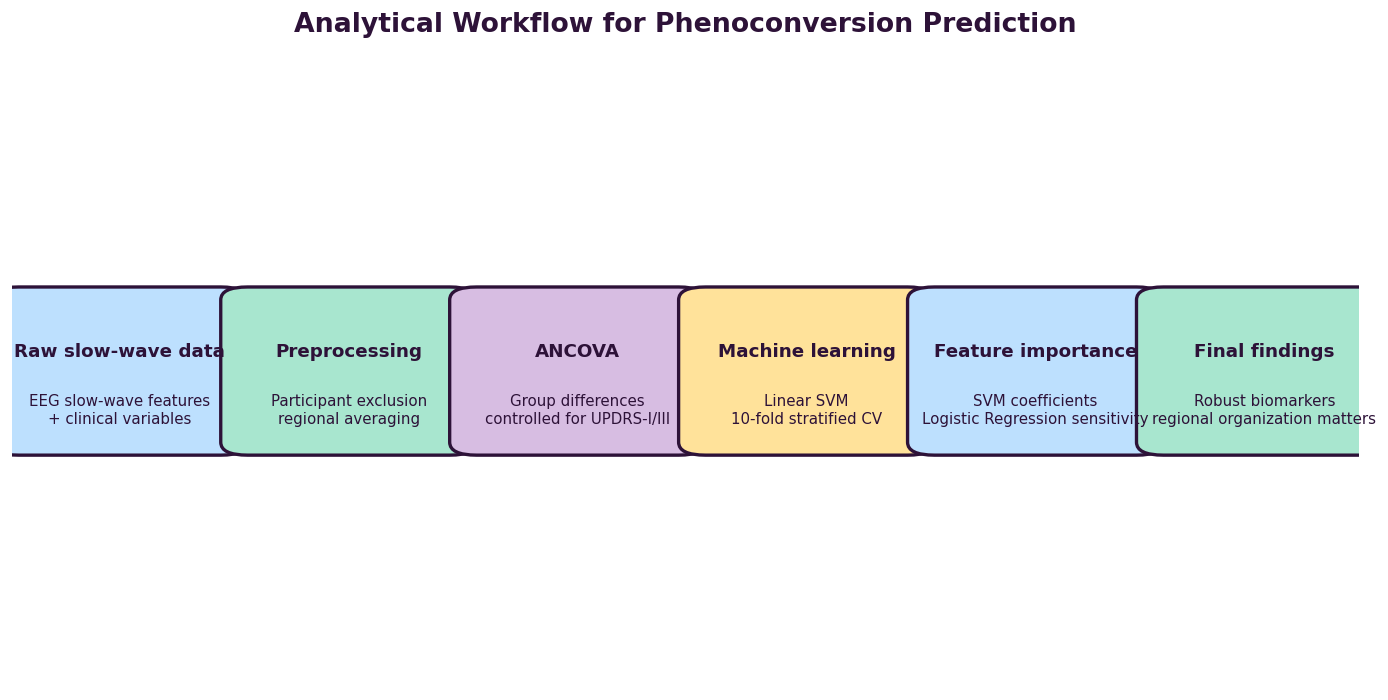

In [65]:
# essaie de figure pour illsutrer ma présentation finale 
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

PROJECT_ROOT = Path("..")
FIGURES_DIR = PROJECT_ROOT / "figures" / "presentation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

palette = {
    "dark": "#2D1238",
    "frontal": "#BDE0FE",
    "central": "#A8E6CF",
    "parietal": "#D7BDE2",
    "occipital": "#FFE29A",
    "gray": "#6C757D",
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

steps = [
    ("Raw slow-wave data", "EEG slow-wave features\n+ clinical variables"),
    ("Preprocessing", "Participant exclusion\nregional averaging"),
    ("ANCOVA", "Group differences\ncontrolled for UPDRS-I/III"),
    ("Machine learning", "Linear SVM\n10-fold stratified CV"),
    ("Feature importance", "SVM coefficients\nLogistic Regression sensitivity"),
    ("Final findings", "Robust biomarkers\nregional organization matters"),
]

x_positions = [0.08, 0.25, 0.42, 0.59, 0.76, 0.93]
colors = [
    palette["frontal"],
    palette["central"],
    palette["parietal"],
    palette["occipital"],
    palette["frontal"],
    palette["central"],
]

for i, ((title, subtitle), x, color) in enumerate(zip(steps, x_positions, colors)):
    box = FancyBboxPatch(
        (x - 0.075, 0.38),
        0.15,
        0.22,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor=palette["dark"],
        linewidth=2,
    )
    ax.add_patch(box)

    ax.text(
        x, 0.52, title,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x, 0.43, subtitle,
        ha="center",
        va="center",
        fontsize=9,
        color=palette["dark"],
    )

    if i < len(steps) - 1:
        ax.add_patch(
            FancyArrowPatch(
                (x + 0.08, 0.49),
                (x_positions[i + 1] - 0.08, 0.49),
                arrowstyle="->",
                mutation_scale=18,
                linewidth=2,
                color=palette["dark"],
            )
        )

ax.set_title(
    "Analytical Workflow for Phenoconversion Prediction",
    fontsize=16,
    fontweight="bold",
    color=palette["dark"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "presentation_workflow_schema.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

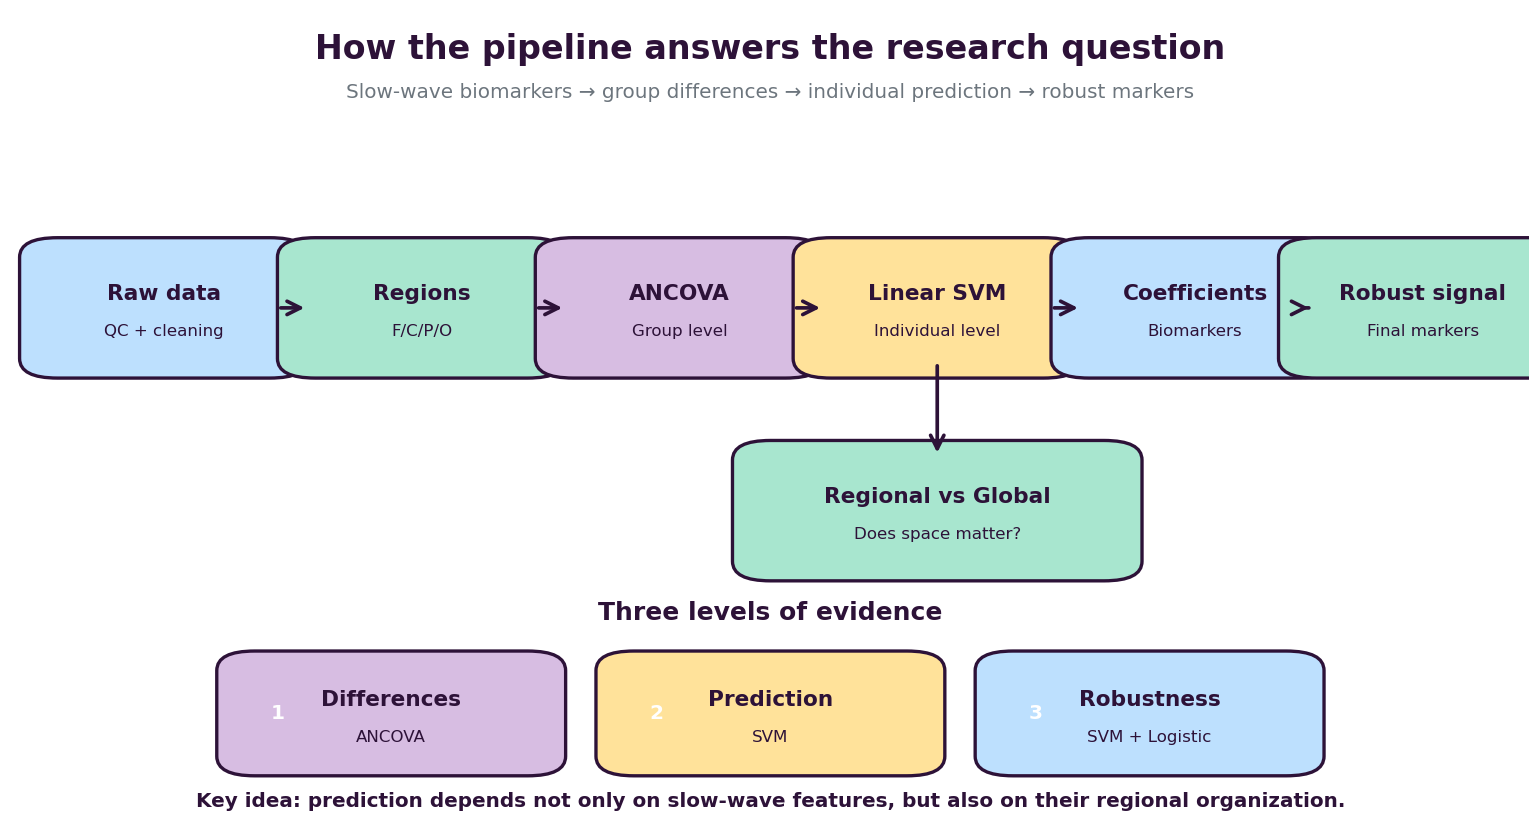

In [67]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

PROJECT_ROOT = Path("..")
FIGURES_DIR = PROJECT_ROOT / "figures" / "presentation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

palette = {
    "dark": "#2D1238",
    "gray": "#6C757D",
    "frontal": "#BDE0FE",
    "central": "#A8E6CF",
    "parietal": "#D7BDE2",
    "occipital": "#FFE29A",
    "white": "#FFFFFF",
}

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

def box(x, y, title, subtitle, color, w=0.19, h=0.13):
    patch = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle="round,pad=0.025",
        facecolor=color,
        edgecolor=palette["dark"],
        linewidth=2,
    )
    ax.add_patch(patch)

    ax.text(
        x,
        y + 0.018,
        title,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=palette["dark"],
    )

    ax.text(
        x,
        y - 0.030,
        subtitle,
        ha="center",
        va="center",
        fontsize=10,
        color=palette["dark"],
    )

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=20,
            linewidth=2.2,
            color=palette["dark"],
        )
    )

# Title
ax.text(
    0.5,
    0.94,
    "How the pipeline answers the research question",
    ha="center",
    fontsize=20,
    fontweight="bold",
    color=palette["dark"],
)

ax.text(
    0.5,
    0.89,
    "Slow-wave biomarkers → group differences → individual prediction → robust markers",
    ha="center",
    fontsize=12,
    color=palette["gray"],
)

# Main pipeline
pipeline = [
    ("Raw data", "QC + cleaning", 0.10, palette["frontal"]),
    ("Regions", "F/C/P/O", 0.27, palette["central"]),
    ("ANCOVA", "Group level", 0.44, palette["parietal"]),
    ("Linear SVM", "Individual level", 0.61, palette["occipital"]),
    ("Coefficients", "Biomarkers", 0.78, palette["frontal"]),
    ("Robust signal", "Final markers", 0.93, palette["central"]),
]

y_main = 0.62

for title, subtitle, x, color in pipeline:
    box(x, y_main, title, subtitle, color, w=0.14, h=0.13)

for i in range(len(pipeline) - 1):
    arrow(
        pipeline[i][2] + 0.075,
        y_main,
        pipeline[i + 1][2] - 0.075,
        y_main,
    )

# Branch: regional vs global
box(
    0.61,
    0.36,
    "Regional vs Global",
    "Does space matter?",
    palette["central"],
    w=0.22,
    h=0.13,
)

arrow(0.61, 0.55, 0.61, 0.43)

# Three answer levels
ax.text(
    0.5,
    0.22,
    "Three levels of evidence",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color=palette["dark"],
)

answer_boxes = [
    ("1", "Differences", "ANCOVA", 0.25, palette["parietal"]),
    ("2", "Prediction", "SVM", 0.50, palette["occipital"]),
    ("3", "Robustness", "SVM + Logistic", 0.75, palette["frontal"]),
]

for number, title, subtitle, x, color in answer_boxes:
    circle = plt.Circle(
        (x - 0.075, 0.10),
        0.035,
        facecolor=palette["dark"],
        edgecolor=palette["dark"],
    )
    ax.add_patch(circle)

    ax.text(
        x - 0.075,
        0.10,
        number,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white",
    )

    box(
        x,
        0.10,
        title,
        subtitle,
        color,
        w=0.18,
        h=0.11,
    )

# Key message
ax.text(
    0.5,
    -0.02,
    "Key idea: prediction depends not only on slow-wave features, but also on their regional organization.",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=palette["dark"],
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "visual_methods_pipeline.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()